# Composition analysis

This notebook studies how much neighborhood marker composition explains local curvature predictions.
It follows the current `train_single_model.ipynb` data-preparation conventions while keeping global graph features optional through `USE_GLOBAL_FEATURES`.

The experiments are:
1. original validation ego-subgraphs
2. center-preserving neighborhood permutation
3. ring-preserving permutation


## Setup and training

### Specify model and training parameters

In [1]:
import copy
import inspect
import json
import math
import pickle
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())


PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


In [2]:
# Data and target settings
EXPERIMENT_GROUP = "signal_composition_analysis"
DATA_SUBDIR = "mean_curvature_smooth"
TARGET_INDICES = [0]
TARGET_LABELS_ALL = {
    0: "Gaussian curvature",
    1: "Mean curvature",
}
TARGET_LABELS = [TARGET_LABELS_ALL.get(i, f"target {i}") for i in TARGET_INDICES]
USE_GLOBAL_FEATURES = True
FEATURE_VARIANTS = {
    "with_global" if USE_GLOBAL_FEATURES else "without_global": USE_GLOBAL_FEATURES,
}
VARIANT_SUFFIX = {
    "with_global": "global",
    "without_global": "no-global",
}

# Filtering and preprocessing settings
FILL_MISSING_COMPLEXITY = True
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
SPHERICITY_MAX = 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
COMPLEXITY_MIN = 2.0
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

# Split and sampling settings
VAL_FRAC = 0.2
SPLIT_SEED = 0
FORCED_VAL_KEYS = set()
K_MAX = 6
DEPTHS = np.arange(0, K_MAX)

# Model settings
MODEL_FAMILIES = ["GIN", "ring-fraction", "ring-size"]
BASE_HIDDEN_DIM = 2 * 64
BASE_DROPOUT = 0.1
BASE_NORM = "batch"

# Training settings
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 2000
PATIENCE = 30
NUM_WORKERS = 4
EDGE_LOSS_WEIGHT = 0.2

# Experiment output settings
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = f"run_{RUN_TIMESTAMP}"
SAVE_DIR = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"


In [3]:
def _safe_filename(name):
    text = str(name).strip().replace("/", "_")
    chars = [ch if (ch.isalnum() or ch in "._-") else "_" for ch in text]
    cleaned = "".join(chars).strip("._-")
    while "__" in cleaned:
        cleaned = cleaned.replace("__", "_")
    return cleaned or "figure"


def ensure_figure_dir():
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    return FIGURES_DIR


def save_mpl_figure(fig, name, *, close=False):
    path = ensure_figure_dir() / f"{_safe_filename(name)}.pdf"
    fig.savefig(path, bbox_inches="tight", transparent=True)
    print(f"Saved figure -> {path}")
    if close:
        plt.close(fig)
    return path


def save_current_mpl_figure(name, *, close=False):
    return save_mpl_figure(plt.gcf(), name, close=close)


def save_plotly_figure(fig, name, *, scale=2):
    path = ensure_figure_dir() / f"{_safe_filename(name)}.png"
    try:
        fig.write_image(str(path), scale=scale)
        print(f"Saved Plotly figure -> {path}")
    except Exception as exc:
        print(f"Could not save Plotly figure as PNG at {path}: {exc}")
    return path


### Load and process data

In [4]:

from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    add_log_metadata_features,
    attach_metadata_to_graphs,
    fill_missing_metadata_for_group,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    print_graph_and_metadata_fields,
    promote_metadata_to_graph_tensors,
)
from src.data.filters import (
    filter_graphs_by_marker_diversity,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors

data_dir = DATA_ROOT / DATA_SUBDIR

graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")
if graphs:
    print("Raw y shape:", tuple(graphs[0].y.shape))

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(graphs, meta, exclude_keys=None)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

marker_names = load_marker_names_from_dir(str(data_dir))

graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
if graphs:
    print("Selected y shape:", tuple(graphs[0].y.shape))

if marker_names is None:
    n_markers = int(graphs[0].x.size(1)) if graphs else 0
    marker_names = [f"marker_{i}" for i in range(n_markers)]

print(f"Loaded {len(marker_names)} markers.")
print_graph_and_metadata_fields(graphs)


Loaded 1134 graphs; skipped 0.
Loaded 1134 organoids.
Raw y shape: (265, 2)
Attached metadata to 1134/1134 graphs.
Selected y shape: (265,)
Loaded 7 markers.
Graph fields:
  - _edge_attr_cls
  - _store
  - _tensor_attr_cls

Metadata fields (g.meta):
  - cell_patch_area
  - complexity
  - d_crypts_graph
  - d_crypts_mesh_shape
  - dataset
  - deleted_node_ids
  - graph_path
  - kept_node_ids
  - label_uid
  - mean_gaussian_curvature
  - mean_mean_curvature
  - mesh_path
  - new_to_old_index
  - num_deleted_nodes
  - num_nodes
  - old_to_new_index
  - organoid_id
  - original_num_nodes
  - proj_vertex_ids
  - segmentation_path
  - timepoint
  - total_curvature_discrete
  - total_mean_curvature_discrete
  - total_surface_area
  - total_volume
  - voronoi_vertex_owner
  - y_columns


In [5]:

if FILL_MISSING_COMPLEXITY:
    graphs = fill_missing_metadata_for_group(
        graphs,
        field="complexity",
        fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
        dataset=MISSING_COMPLEXITY_GROUP["dataset"],
        timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
    )

graphs, g_spherical = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=SPHERICITY_MAX,
    print_summary=True,
    return_rejected=True,
)

g_spherical = filter_graphs_by_marker_diversity(
    g_spherical,
    min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
    print_summary=True,
)

graphs = filter_graphs_by_numeric_metadata(
    graphs,
    key="complexity",
    min_value=COMPLEXITY_MIN,
    allow_missing=False,
    inplace=False,
    print_summary=True,
)

graphs = graphs + g_spherical
print(f"After filtering and spherical rescue: {len(graphs)} organoids.")


filter_graphs_by_sphericity(max_sphericity=0.92): kept 819 / 1134 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                244    342    0.713
20250929         day4p5               89    104    0.856
20250929         day4p5-more         290    411    0.706
20251201         day4p5              196    277    0.708
filter_graphs_by_marker_diversity(min_score=0.5, top_k=None): kept 93 / 315 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                 37     98    0.378
20250929         day4p5                9     15    0.600
20250929         day4p5-more          27    121    0.223
20251201         day4p5               20     81    0.247
filter_graphs_by_numeric_metadata(key='complexity', min_value=2.0, max_value=None): kept 712 / 819 graphs

dataset          timepoint          kept  total

In [6]:

if INTERPOLATE_TARGET_OUTLIERS:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        target_indices=None,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    outlier_info = None

field_specs = []

if USE_GLOBAL_FEATURES:
    graphs = add_log_metadata_features(graphs, inplace=False)
    field_specs = [
        {
            "meta_keys": [
                "log_surface_area",
                "log_volume",
                "log_volume_over_area",
                "log_num_cells",
            ],
            "attr_name": "global_feat",
            "kind": "graph_vector",
            "dtype": torch.float32,
        },
    ]
    graphs = promote_metadata_to_graph_tensors(graphs, field_specs, inplace=False)
    print("Promoted metadata fields to graph tensor attributes.")
else:
    print("Global features disabled; no global_feat attribute was attached.")


=== Target outlier interpolation report ===
Quantiles: (0.005, 0.995)
target 0: range=[-0.364722, 0.315371] | outliers=3766 | replaced=3766 | fallback=971
Promoted metadata fields to graph tensor attributes.


In [7]:

from src.data.splits import graph_metadata_key, train_val_split_graphs
from src.data.metadata import snapshot_graph_metadata, strip_graph_metadata

# Split while metadata is still attached.
base_train, base_val, split_info = train_val_split_graphs(
    graphs,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    force_val_keys=FORCED_VAL_KEYS,
    key_fn=graph_metadata_key,
)
print(f"Split -> train: {len(base_train)} | val: {len(base_val)}")

# Save validation metadata lookup before stripping metadata.
val_meta_lookup = snapshot_graph_metadata(base_val)

# Strip metadata after the split and after the snapshot.
base_train = strip_graph_metadata(base_train, inplace=False)
base_val = strip_graph_metadata(base_val, inplace=False)


Split -> train: 644 | val: 161


In [8]:

from src.data.metadata import infer_global_dim
from src.data.ring_features import attach_precomputed_ring_features
from src.data.target_transforms import AsinhStandardizeTransform, standardize_graph_global_features

def remove_attr_from_graphs(graphs, attr_name):
    graphs_out = [copy.copy(g) for g in graphs]
    for g in graphs_out:
        if hasattr(g, attr_name):
            delattr(g, attr_name)
    return graphs_out


def prepare_graph_variant(train_graphs, val_graphs, *, use_global_features: bool):
    g_train = copy.deepcopy(train_graphs)
    g_val = copy.deepcopy(val_graphs)

    target_transform = AsinhStandardizeTransform(robust=True).fit(g_train)
    target_transform.transform_graphs(g_train)
    target_transform.transform_graphs(g_val)

    center_global, scale_global = None, None
    global_dim = 0

    if use_global_features:
        if not hasattr(g_train[0], "global_feat"):
            raise AttributeError("USE_GLOBAL_FEATURES=True requires global_feat on graphs.")
        center_global, scale_global = standardize_graph_global_features(
            g_train,
            g_val,
            attr_name="global_feat",
            robust=False,
        )
        global_dim = infer_global_dim(g_train)
    else:
        g_train = remove_attr_from_graphs(g_train, "global_feat")
        g_val = remove_attr_from_graphs(g_val, "global_feat")

    g_train = attach_precomputed_ring_features(
        g_train,
        k_hops=K_MAX,
        inplace=False,
    )
    g_val = attach_precomputed_ring_features(
        g_val,
        k_hops=K_MAX,
        inplace=False,
    )

    return {
        "g_train": g_train,
        "g_val": g_val,
        "target_transform": target_transform,
        "center_global": center_global,
        "scale_global": scale_global,
        "global_dim": global_dim,
    }

variant_data = {
    variant_name: prepare_graph_variant(
        base_train,
        base_val,
        use_global_features=use_global,
    )
    for variant_name, use_global in FEATURE_VARIANTS.items()
}

for variant_name, pack in variant_data.items():
    print(
        f"{variant_name:>14s} | "
        f"train={len(pack['g_train'])} | val={len(pack['g_val'])} | "
        f"global_dim={pack['global_dim']}"
    )


   with_global | train=644 | val=161 | global_dim=4


### Train models on organoid graphs

In [9]:

from src.models.gnn import GINCurvature
from src.models.ring_mlp import RingFractionMLP, RingSizeMLP
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term

aux_losses = [
    WeightedLossTerm(
        name="edge",
        fn=edge_loss_term,
        weight=EDGE_LOSS_WEIGHT,
        params={
            "weighted": False,
            "alpha": 2.0,
            "normalize_by": "graph_std",
            "clip_weight": 4.0,
        },
    ),
]

cfg = TrainConfig(
    lr=LR,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    num_workers=NUM_WORKERS,
    aux_losses=aux_losses,
)

device = cfg.device if "cfg" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")
print("Training device:", device)

def _set_global_dim_kwarg(model_cls, model_kwargs, global_dim):
    signature = inspect.signature(model_cls.__init__)
    for key in ("global_dim", "n_global", "num_global_features", "global_feature_dim"):
        if key in signature.parameters:
            model_kwargs[key] = int(global_dim)
            return key
    if int(global_dim) > 0:
        raise TypeError(
            f"{model_cls.__name__} does not expose a recognized global-feature kwarg. "
            "Please update _set_global_dim_kwarg for the current model signature."
        )
    return None

def build_model(family, *, n_markers, depth_or_k, global_dim):
    if family == "GIN":
        model_kwargs = {
            "n_markers": n_markers,
            "hidden_dim": BASE_HIDDEN_DIM,
            "num_layers": int(depth_or_k),
            "dropout": BASE_DROPOUT,
            "residual": True,
            "norm": BASE_NORM,
            "train_eps": True,
        }
        _set_global_dim_kwarg(GINCurvature, model_kwargs, global_dim)
        return GINCurvature(**model_kwargs), model_kwargs

    if family == "ring-fraction":
        model_kwargs = {
            "n_markers": n_markers,
            "k_hops": int(depth_or_k),
            "hidden_dim": BASE_HIDDEN_DIM,
            "dropout": BASE_DROPOUT,
            "norm": BASE_NORM,
        }
        _set_global_dim_kwarg(RingFractionMLP, model_kwargs, global_dim)
        return RingFractionMLP(**model_kwargs), model_kwargs

    if family == "ring-size":
        model_kwargs = {
            "n_markers": n_markers,
            "k_hops": int(depth_or_k),
            "hidden_dim": BASE_HIDDEN_DIM,
            "dropout": BASE_DROPOUT,
            "norm": BASE_NORM,
        }
        _set_global_dim_kwarg(RingSizeMLP, model_kwargs, global_dim)
        return RingSizeMLP(**model_kwargs), model_kwargs

    raise ValueError(f"Unknown family: {family}")

trained_models_by_variant = {
    variant_name: {family: [] for family in MODEL_FAMILIES}
    for variant_name in FEATURE_VARIANTS
}
training_logs = {
    variant_name: {family: [] for family in MODEL_FAMILIES}
    for variant_name in FEATURE_VARIANTS
}

for variant_name, pack in variant_data.items():
    g_train = pack["g_train"]
    g_val = pack["g_val"]
    global_dim = pack["global_dim"]

    for family in MODEL_FAMILIES:
        for k in DEPTHS:
            print(f"\n=== Training {family} | {variant_name} | depth={k} ===")

            n_markers = int(g_train[0].x.size(1))
            model, model_kwargs = build_model(
                family,
                n_markers=n_markers,
                depth_or_k=int(k),
                global_dim=global_dim,
            )

            model, metrics, history = train(model, g_train, g_val, cfg)
            trained_models_by_variant[variant_name][family].append(model)
            training_logs[variant_name][family].append(
                {
                    "depth": int(k),
                    "model_kwargs": model_kwargs,
                    "metrics": metrics,
                    "history": history,
                }
            )


Training device: cuda

=== Training GIN | with_global | depth=0 ===
epoch 001 | train loss 0.6326 mae 0.8687 | val loss 0.5676 mae 0.8128
epoch 002 | train loss 0.6064 mae 0.8455 | val loss 0.5505 mae 0.7971
epoch 003 | train loss 0.5853 mae 0.8260 | val loss 0.5354 mae 0.7835
epoch 004 | train loss 0.5677 mae 0.8085 | val loss 0.5213 mae 0.7713
epoch 005 | train loss 0.5520 mae 0.7933 | val loss 0.5086 mae 0.7612
epoch 006 | train loss 0.5386 mae 0.7812 | val loss 0.4972 mae 0.7526
epoch 007 | train loss 0.5263 mae 0.7703 | val loss 0.4867 mae 0.7453
epoch 008 | train loss 0.5152 mae 0.7613 | val loss 0.4775 mae 0.7396
epoch 009 | train loss 0.5064 mae 0.7549 | val loss 0.4687 mae 0.7349
epoch 010 | train loss 0.4978 mae 0.7495 | val loss 0.4611 mae 0.7311
epoch 011 | train loss 0.4909 mae 0.7454 | val loss 0.4544 mae 0.7281
epoch 012 | train loss 0.4852 mae 0.7424 | val loss 0.4488 mae 0.7259
epoch 013 | train loss 0.4808 mae 0.7404 | val loss 0.4444 mae 0.7242
epoch 014 | train loss

## Prepare validation data for experiments

For ego-subgraph evaluation, ring-based features are recomputed on the ego-subgraphs on the fly. This is still valid because:
- the subgraphs are built with radius `K_MAX`
- we evaluate only the center node of each subgraph
- the center node therefore has access to its full neighborhood up to `k <= K_MAX`


In [10]:

from src.data.subgraphs import build_ego_subgraphs_for_dataset
from src.data.subgraph_sampling import sample_subgraphs_coverage, print_sampling_summary

sampled_val_subgraphs_by_variant = {}
sample_info_by_variant = {}

for variant_name, pack in variant_data.items():
    val_subgraphs = build_ego_subgraphs_for_dataset(
        pack["g_val"],
        num_hops=K_MAX,
        max_centers_per_graph=None,
        seed=0,
    )

    sampled_val_subgraphs, sample_info = sample_subgraphs_coverage(
        val_subgraphs,
        marker_names=marker_names,
        k_hops=K_MAX,
        max_subgraphs=2500,
        min_center_count=40,
        min_pair_count=25,
        seed=0,
    )

    sampled_val_subgraphs_by_variant[variant_name] = sampled_val_subgraphs
    sample_info_by_variant[variant_name] = sample_info

    print(f"\nSampling summary for {variant_name}:")
    print_sampling_summary(sample_info, marker_names)



Sampling summary for with_global:
Selected 2500 / 75455 subgraphs

Center coverage:
Agr2          covered= 203  target=  40  available=3853  OK
AldoB         covered=1034  target=  40  available=32063  OK
Chroma        covered=  93  target=  40  available= 300  OK
KI67          covered= 787  target=  40  available=22839  OK
LGR5          covered= 547  target=  40  available=12590  OK
Lysozyme      covered= 129  target=  40  available=2027  OK
Serotonin     covered=  93  target=  40  available= 272  OK

Unsatisfied center markers: []
Unsatisfied pair features: 1


### Setup helper functions for analysis

In [11]:

from src.analysis.prediction_analysis import eval_model_per_marker

def evaluate_family_models(trained_models, eval_subgraphs, device, target_transform, *, center_only=True):
    all_results = {}

    aggregate_keys = ["any_marker", "no_marker", "all_nodes"]
    aggregate_metric_keys = [
        "n",
        "mse_model", "sem_mse_model",
        "mse_base", "sem_mse_base",
        "var_model", "sem_var_model",
        "var_base", "sem_var_base",
        "nll_model", "sem_nll_model",
        "nll_base", "sem_nll_base",
        "rho", "pval",
    ]

    for family, models in trained_models.items():
        fam_mse_model = []
        fam_sem_mse_model = []
        fam_var_model = []
        fam_sem_var_model = []
        fam_nll_model = []
        fam_sem_nll_model = []
        fam_rho_marker = []
        fam_pval_marker = []
        fam_n_pos_corr = []
        fam_rho_global = []
        fam_pval_global = []

        fam_mse_base = None
        fam_var_base = None
        fam_sem_mse_base = None
        fam_nll_base = None
        fam_sem_nll_base = None

        fam_aggregate = {
            agg_name: {metric: [] for metric in aggregate_metric_keys}
            for agg_name in aggregate_keys
        }

        for model in models:
            model.eval()
            out = eval_model_per_marker(
                model,
                eval_subgraphs,
                device=device,
                target_transform=target_transform,
                center_only=center_only,
            )

            fam_mse_model.append(out["mse_model"])
            fam_sem_mse_model.append(out["sem_mse_model"])
            fam_var_model.append(out["var_model"])
            fam_sem_var_model.append(out["sem_var_model"])
            fam_nll_model.append(out["nll_model"])
            fam_sem_nll_model.append(out["sem_nll_model"])
            fam_rho_marker.append(out["rho_marker"])
            fam_pval_marker.append(out["pval_marker"])
            fam_n_pos_corr.append(out["n_pos_corr"])
            fam_rho_global.append(out["rho_global"])
            fam_pval_global.append(out["pval_global"])

            for agg_name in aggregate_keys:
                agg_out = out["aggregate"][agg_name]
                for metric in aggregate_metric_keys:
                    fam_aggregate[agg_name][metric].append(agg_out[metric])

            if fam_mse_base is None:
                fam_mse_base = out["mse_base"]
                fam_var_base = out["var_base"]
                fam_sem_mse_base = out["sem_mse_base"]
                fam_nll_base = out["nll_base"]
                fam_sem_nll_base = out["sem_nll_base"]

        fam_aggregate_stacked = {}
        for agg_name in aggregate_keys:
            fam_aggregate_stacked[agg_name] = {}
            for metric in aggregate_metric_keys:
                fam_aggregate_stacked[agg_name][metric] = np.asarray(
                    fam_aggregate[agg_name][metric],
                    dtype=float,
                )

        all_results[family] = {
            "mse_model": np.stack(fam_mse_model, axis=0),
            "sem_mse_model": np.stack(fam_sem_mse_model, axis=0),
            "var_model": np.stack(fam_var_model, axis=0),
            "sem_var_model": np.stack(fam_sem_var_model, axis=0),
            "nll_model": np.stack(fam_nll_model, axis=0),
            "sem_nll_model": np.stack(fam_sem_nll_model, axis=0),
            "rho_marker": np.stack(fam_rho_marker, axis=0),
            "pval_marker": np.stack(fam_pval_marker, axis=0),
            "n_pos_corr": np.stack(fam_n_pos_corr, axis=0),
            "rho_global": np.asarray(fam_rho_global, dtype=float),
            "pval_global": np.asarray(fam_pval_global, dtype=float),
            "mse_base": fam_mse_base,
            "var_base": fam_var_base,
            "sem_mse_base": fam_sem_mse_base,
            "nll_base": fam_nll_base,
            "sem_nll_base": fam_sem_nll_base,
            "aggregate": fam_aggregate_stacked,
        }

    return all_results

def flatten_variant_results(results_by_variant):
    flat = {}
    for variant_name, family_results in results_by_variant.items():
        suffix = VARIANT_SUFFIX[variant_name]
        for family, result in family_results.items():
            flat[f"{family} | {suffix}"] = result
    return flat

family_colors = {
    "GIN | global": "#1f77b4",
    "GIN | no-global": "#6baed6",
    "ring-fraction | global": "#ff7f0e",
    "ring-fraction | no-global": "#fdae6b",
    "ring-size | global": "#9467bd",
    "ring-size | no-global": "#c5b0d5",
}

family_order = [
    f"{family} | {VARIANT_SUFFIX[variant_name]}"
    for variant_name in FEATURE_VARIANTS
    for family in MODEL_FAMILIES
]

plt.rcParams.update({
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


## Experiment 1: Original organoid graphs

This establishes the baseline behavior of each model family on the original validation ego-subgraphs, with the configured global-feature setting.


In [12]:

all_results_exp1_by_variant = {}

for variant_name, pack in variant_data.items():
    all_results_exp1_by_variant[variant_name] = evaluate_family_models(
        trained_models=trained_models_by_variant[variant_name],
        eval_subgraphs=sampled_val_subgraphs_by_variant[variant_name],
        device=device,
        target_transform=pack["target_transform"],
        center_only=True,
    )

all_results_exp1 = flatten_variant_results(all_results_exp1_by_variant)
print("Experiment 1 families:", list(all_results_exp1.keys()))


Experiment 1 families: ['GIN | global', 'ring-fraction | global', 'ring-size | global']


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/run_20260506_115803/figures/exp1_validation_mse_markerwise_vs_depth.pdf


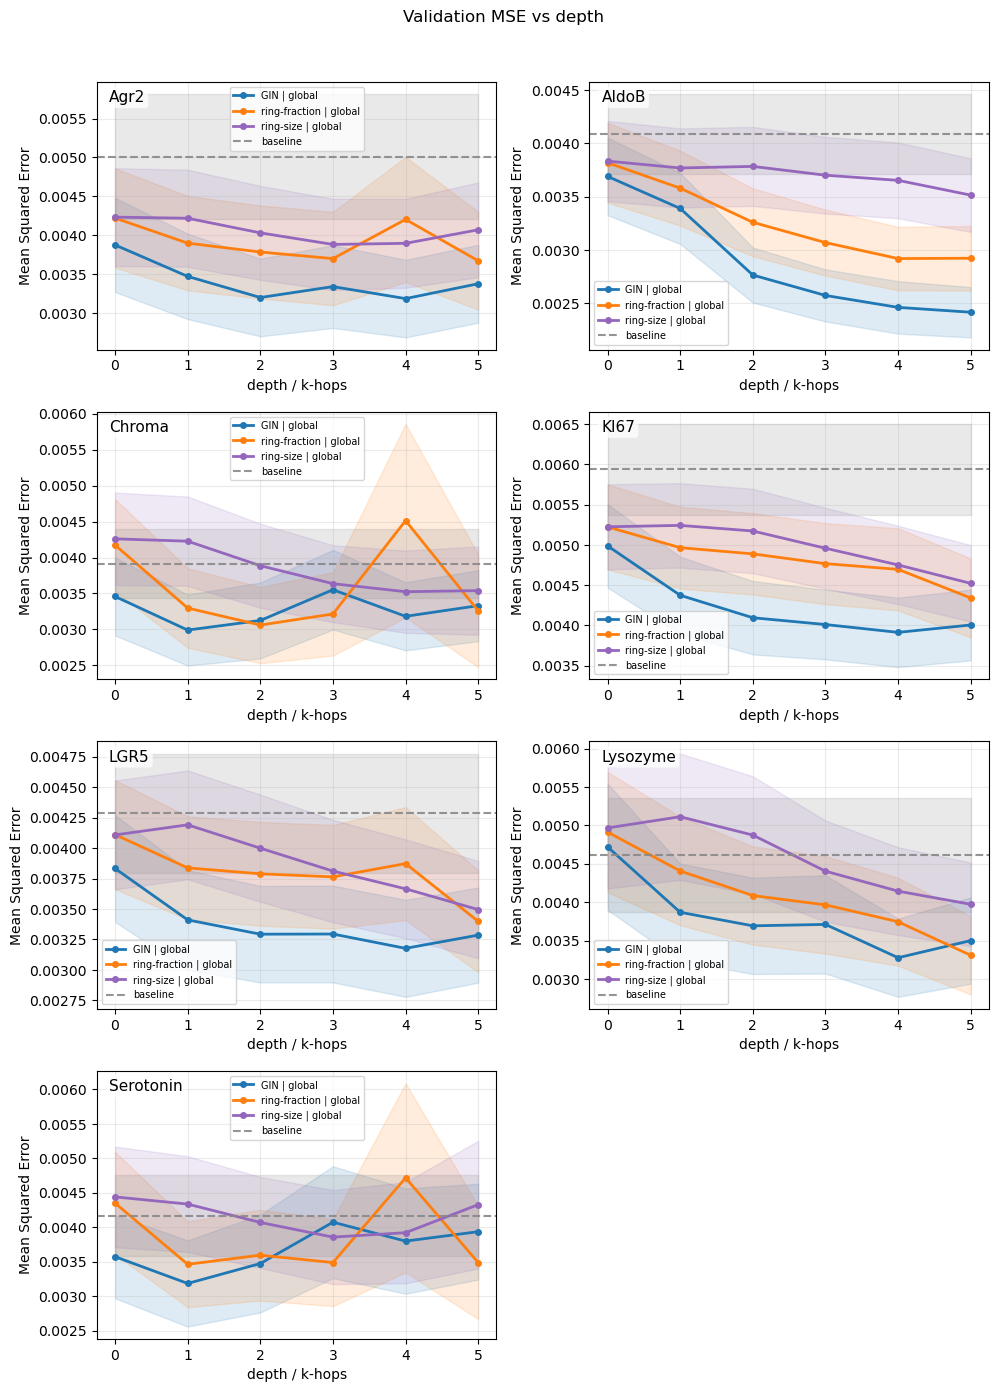

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/run_20260506_115803/figures/exp1_validation_mse_all_nodes_vs_depth.pdf


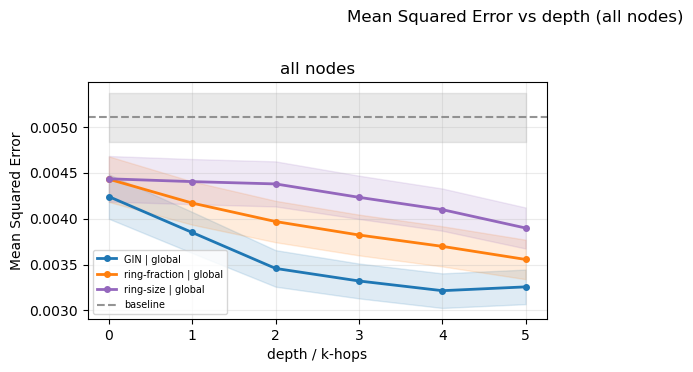

In [13]:
from src.plotting.depth_scan import plot_markerwise_metric_vs_depth, plot_all_aggregates_metric_vs_depth

fig, axes = plot_markerwise_metric_vs_depth(
    all_results=all_results_exp1,
    depths=DEPTHS,
    marker_names=marker_names,
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="Validation MSE vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp1_validation_mse_markerwise_vs_depth")
plt.show()

fig, axes = plot_all_aggregates_metric_vs_depth(
    all_results_exp1,
    DEPTHS,
    aggregate_keys=("all_nodes",),
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="Mean Squared Error vs depth (all nodes)",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp1_validation_mse_all_nodes_vs_depth")
plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/run_20260506_115803/figures/exp1_validation_nll_markerwise_vs_depth.pdf


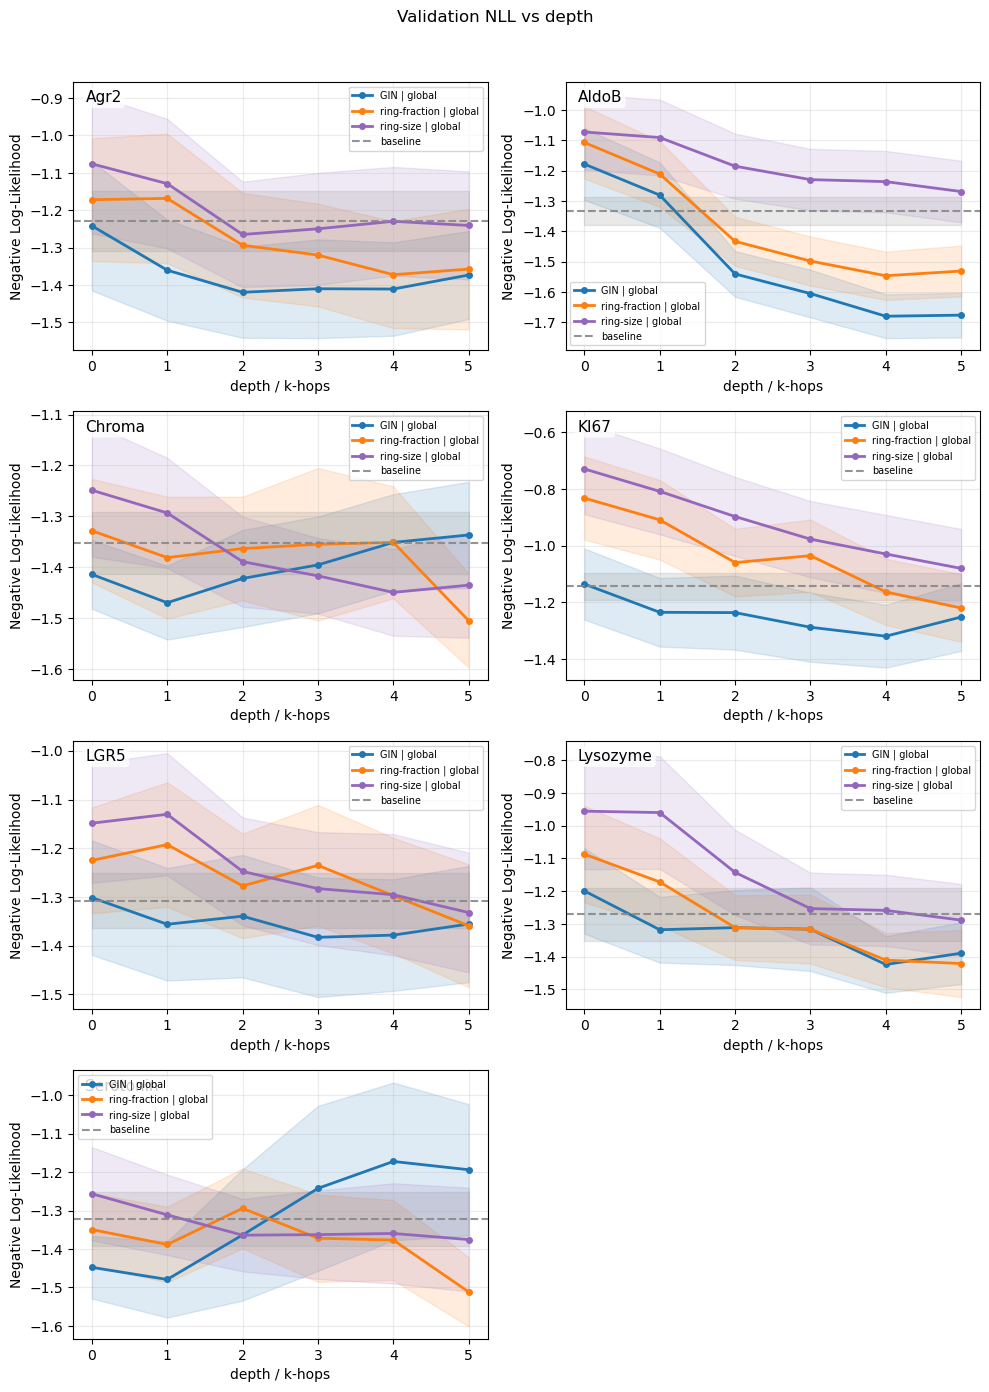

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/run_20260506_115803/figures/exp1_validation_nll_all_nodes_vs_depth.pdf


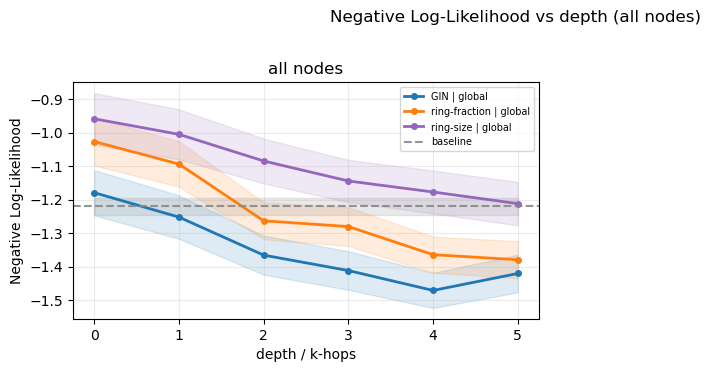

In [14]:
from src.plotting.depth_scan import plot_markerwise_metric_vs_depth, plot_all_aggregates_metric_vs_depth

fig, axes = plot_markerwise_metric_vs_depth(
    all_results=all_results_exp1,
    depths=DEPTHS,
    marker_names=marker_names,
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="Validation NLL vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp1_validation_nll_markerwise_vs_depth")
plt.show()

fig, axes = plot_all_aggregates_metric_vs_depth(
    all_results_exp1,
    DEPTHS,
    aggregate_keys=("all_nodes",),
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="Negative Log-Likelihood vs depth (all nodes)",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp1_validation_nll_all_nodes_vs_depth")
plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/run_20260506_115803/figures/exp1_uncertainty_error_correlation_markerwise_vs_depth.pdf


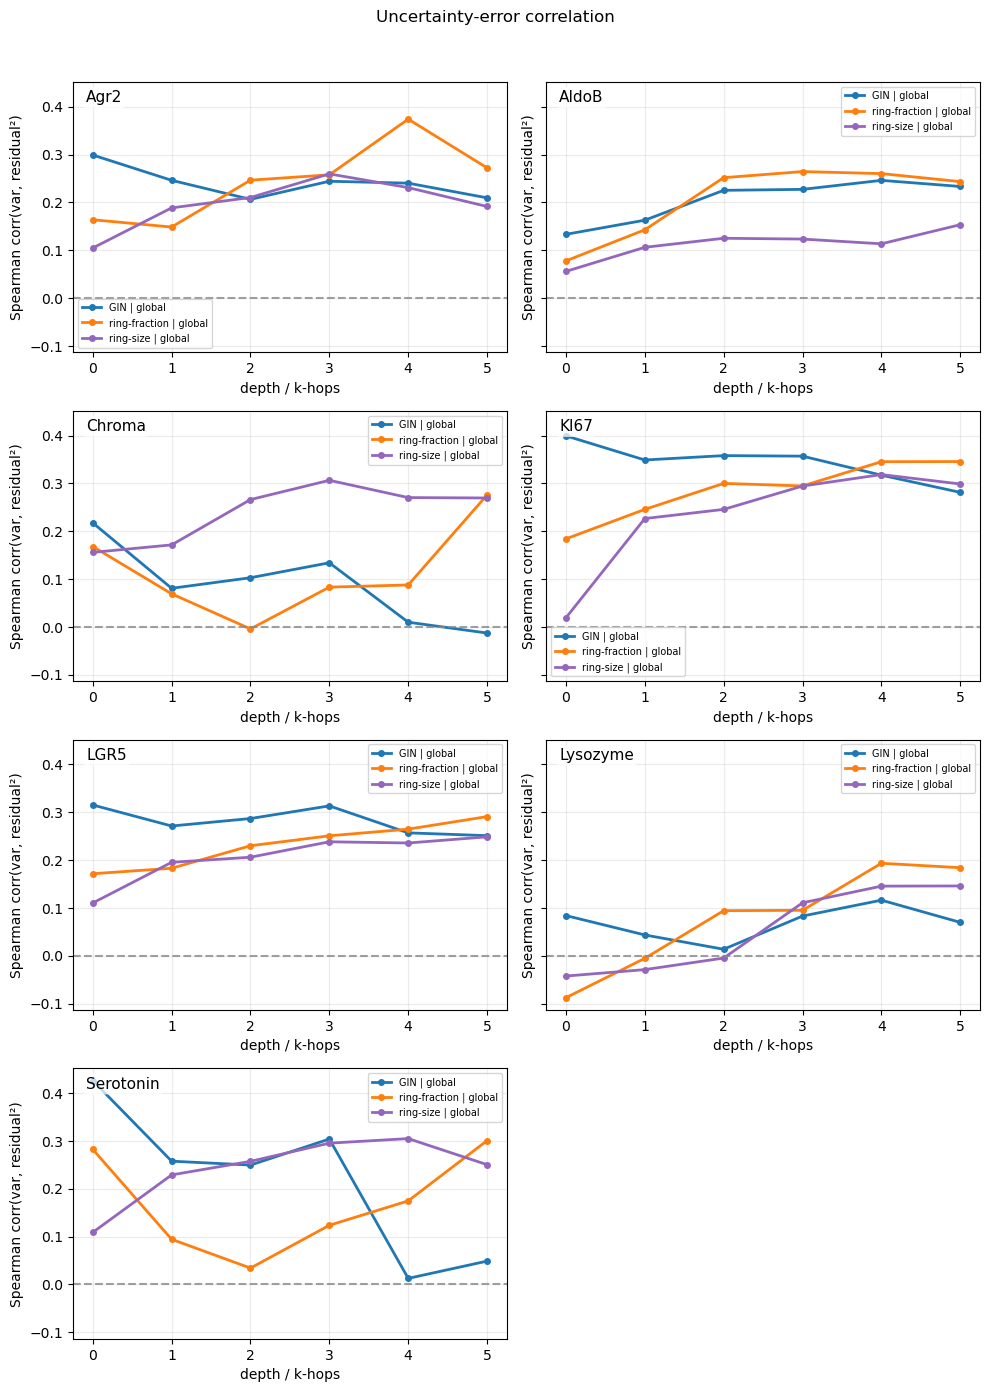

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/run_20260506_115803/figures/exp1_uncertainty_error_correlation_all_nodes_vs_depth.pdf


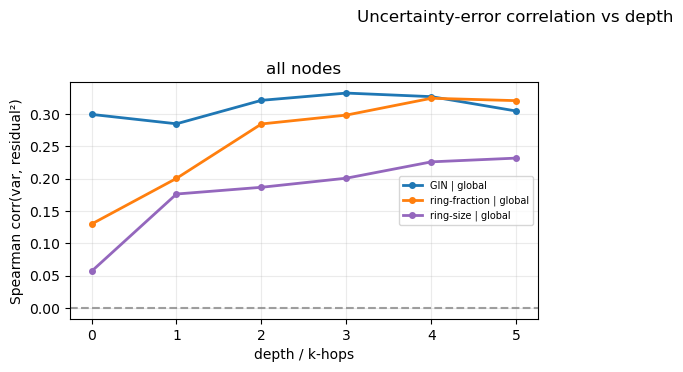

In [15]:
fig, axes = plot_markerwise_metric_vs_depth(
    all_results=all_results_exp1,
    depths=DEPTHS,
    marker_names=marker_names,
    metric_key="rho_marker",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Uncertainty-error correlation",
    family_order=family_order,
    family_colors=family_colors,
    sharey=True,
)
save_mpl_figure(fig, "exp1_uncertainty_error_correlation_markerwise_vs_depth")
plt.show()

fig, axes = plot_all_aggregates_metric_vs_depth(
    all_results_exp1,
    DEPTHS,
    aggregate_keys=("all_nodes",),
    metric_key="rho",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Uncertainty-error correlation vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp1_uncertainty_error_correlation_all_nodes_vs_depth")
plt.show()


## Experiment 2: Center-preserving neighborhood permutation

We reuse the trained models and evaluate them on validation subgraphs whose center marker is preserved while neighborhood markers are permuted within each organoid.


In [16]:

from src.data.permutation import (
    build_center_preserving_permuted_subgraphs,
    permute_graph_features_within_organoid,
)

perm_val_subgraphs_by_variant = {}
all_results_exp2_by_variant = {}

for variant_name, pack in variant_data.items():
    perm_val_subgraphs = build_center_preserving_permuted_subgraphs(
        graphs=pack["g_val"],
        sampled_subgraphs=sampled_val_subgraphs_by_variant[variant_name],
        num_hops=K_MAX,
        permute_graphs_fn=permute_graph_features_within_organoid,
        seed=0,
    )
    perm_val_subgraphs_by_variant[variant_name] = perm_val_subgraphs

    all_results_exp2_by_variant[variant_name] = evaluate_family_models(
        trained_models=trained_models_by_variant[variant_name],
        eval_subgraphs=perm_val_subgraphs,
        device=device,
        target_transform=pack["target_transform"],
        center_only=True,
    )

all_results_exp2 = flatten_variant_results(all_results_exp2_by_variant)
print("Experiment 2 families:", list(all_results_exp2.keys()))


Experiment 2 families: ['GIN | global', 'ring-fraction | global', 'ring-size | global']


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/run_20260506_115803/figures/exp2_center_preserving_mse_markerwise_vs_depth.pdf


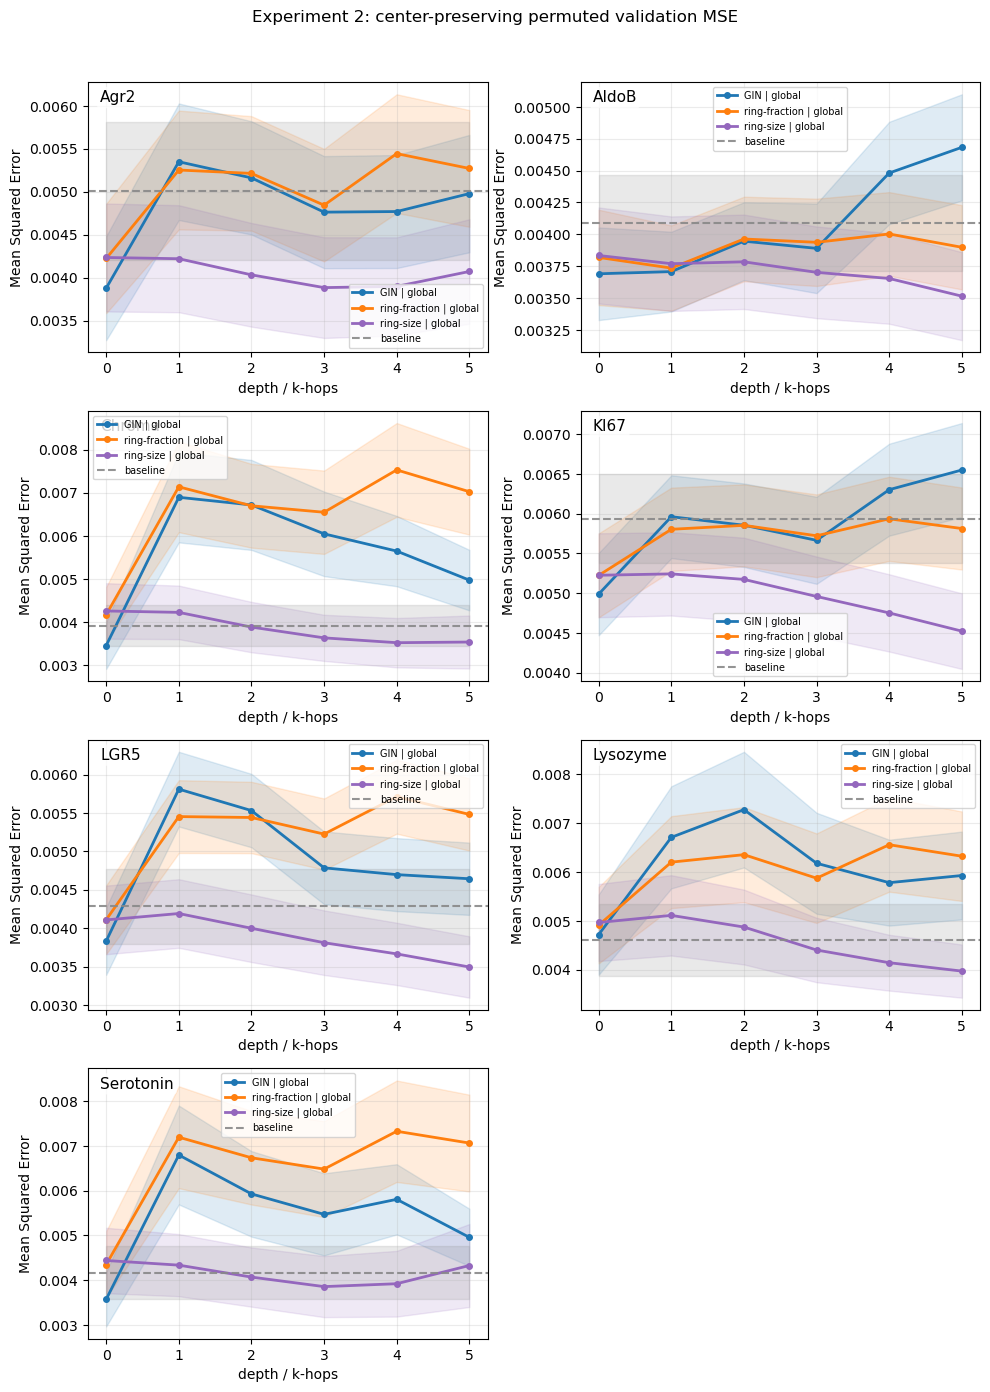

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/run_20260506_115803/figures/exp2_center_preserving_mse_all_nodes_vs_depth.pdf


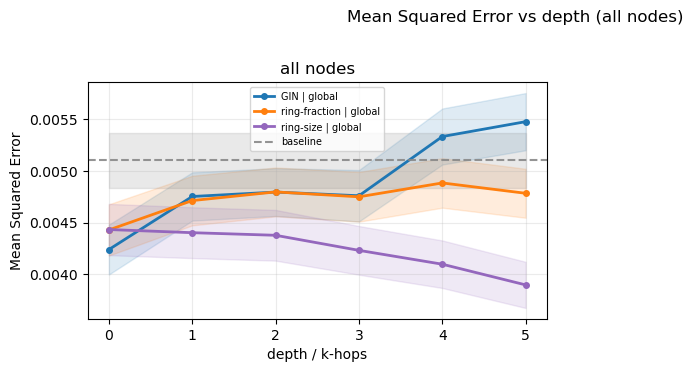

In [17]:
fig, axes = plot_markerwise_metric_vs_depth(
    all_results=all_results_exp2,
    depths=DEPTHS,
    marker_names=marker_names,
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="Experiment 2: center-preserving permuted validation MSE",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp2_center_preserving_mse_markerwise_vs_depth")
plt.show()

fig, axes = plot_all_aggregates_metric_vs_depth(
    all_results_exp2,
    DEPTHS,
    aggregate_keys=("all_nodes",),
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="Mean Squared Error vs depth (all nodes)",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp2_center_preserving_mse_all_nodes_vs_depth")
plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/run_20260506_115803/figures/exp2_center_preserving_nll_markerwise_vs_depth.pdf


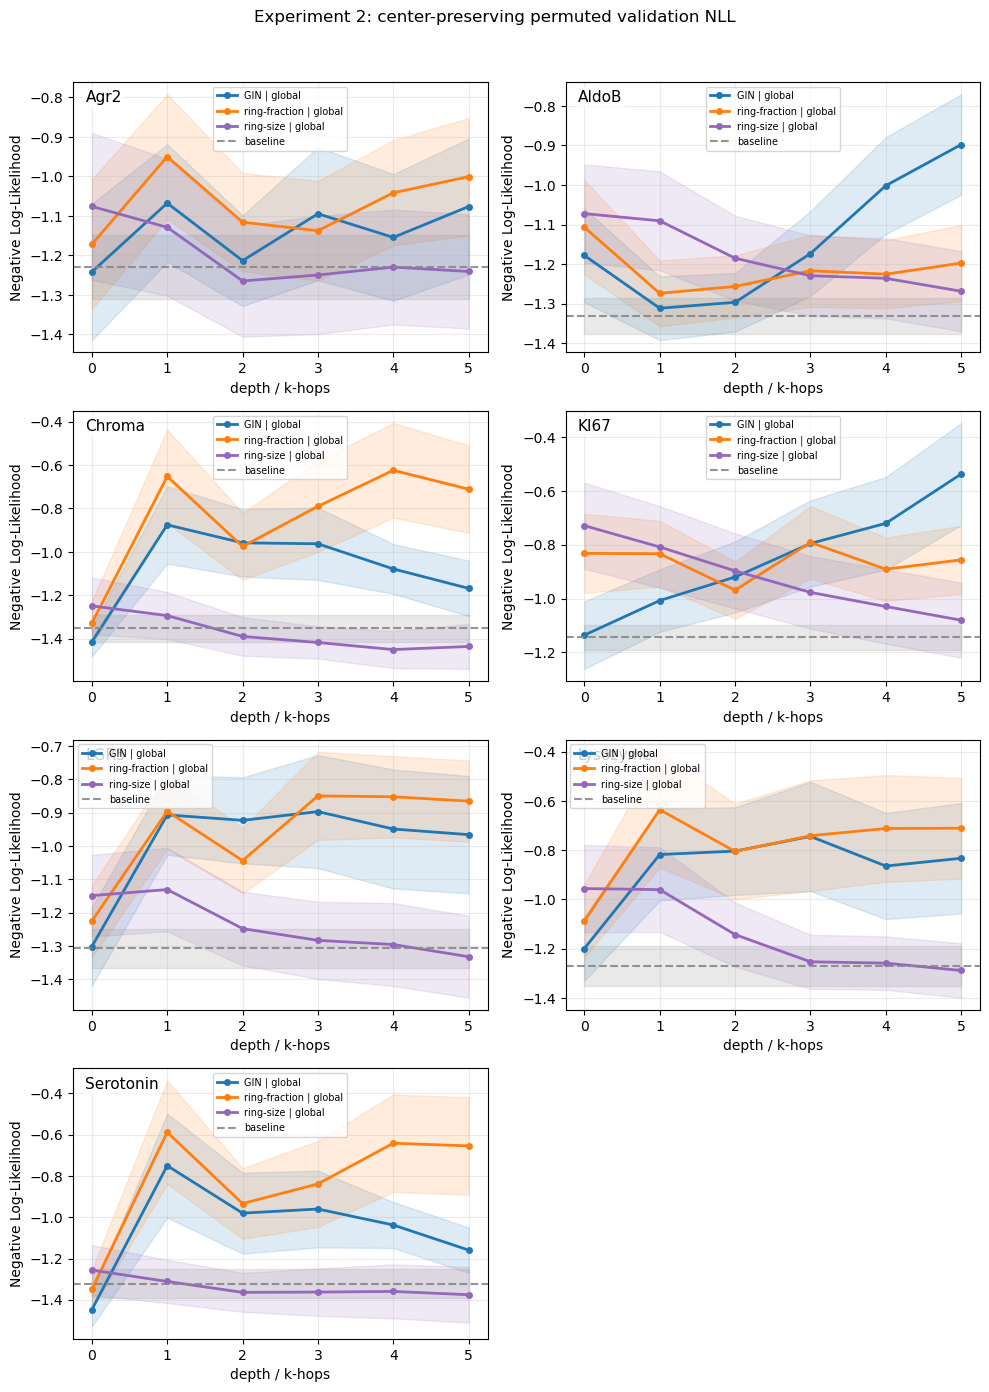

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/run_20260506_115803/figures/exp2_center_preserving_nll_all_nodes_vs_depth.pdf


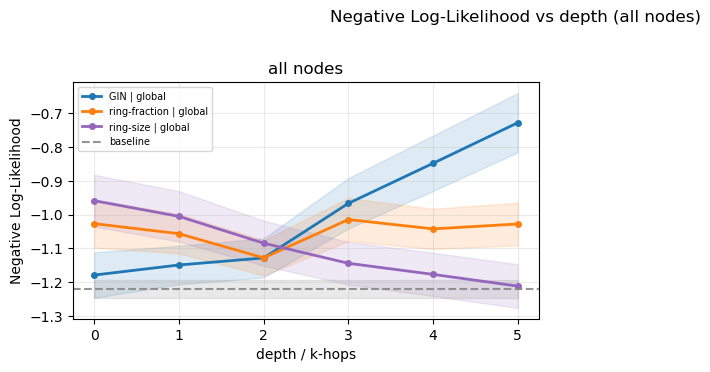

In [18]:
fig, axes = plot_markerwise_metric_vs_depth(
    all_results=all_results_exp2,
    depths=DEPTHS,
    marker_names=marker_names,
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="Experiment 2: center-preserving permuted validation NLL",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp2_center_preserving_nll_markerwise_vs_depth")
plt.show()

fig, axes = plot_all_aggregates_metric_vs_depth(
    all_results_exp2,
    DEPTHS,
    aggregate_keys=("all_nodes",),
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="Negative Log-Likelihood vs depth (all nodes)",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp2_center_preserving_nll_all_nodes_vs_depth")
plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/run_20260506_115803/figures/exp2_uncertainty_error_correlation_markerwise_vs_depth.pdf


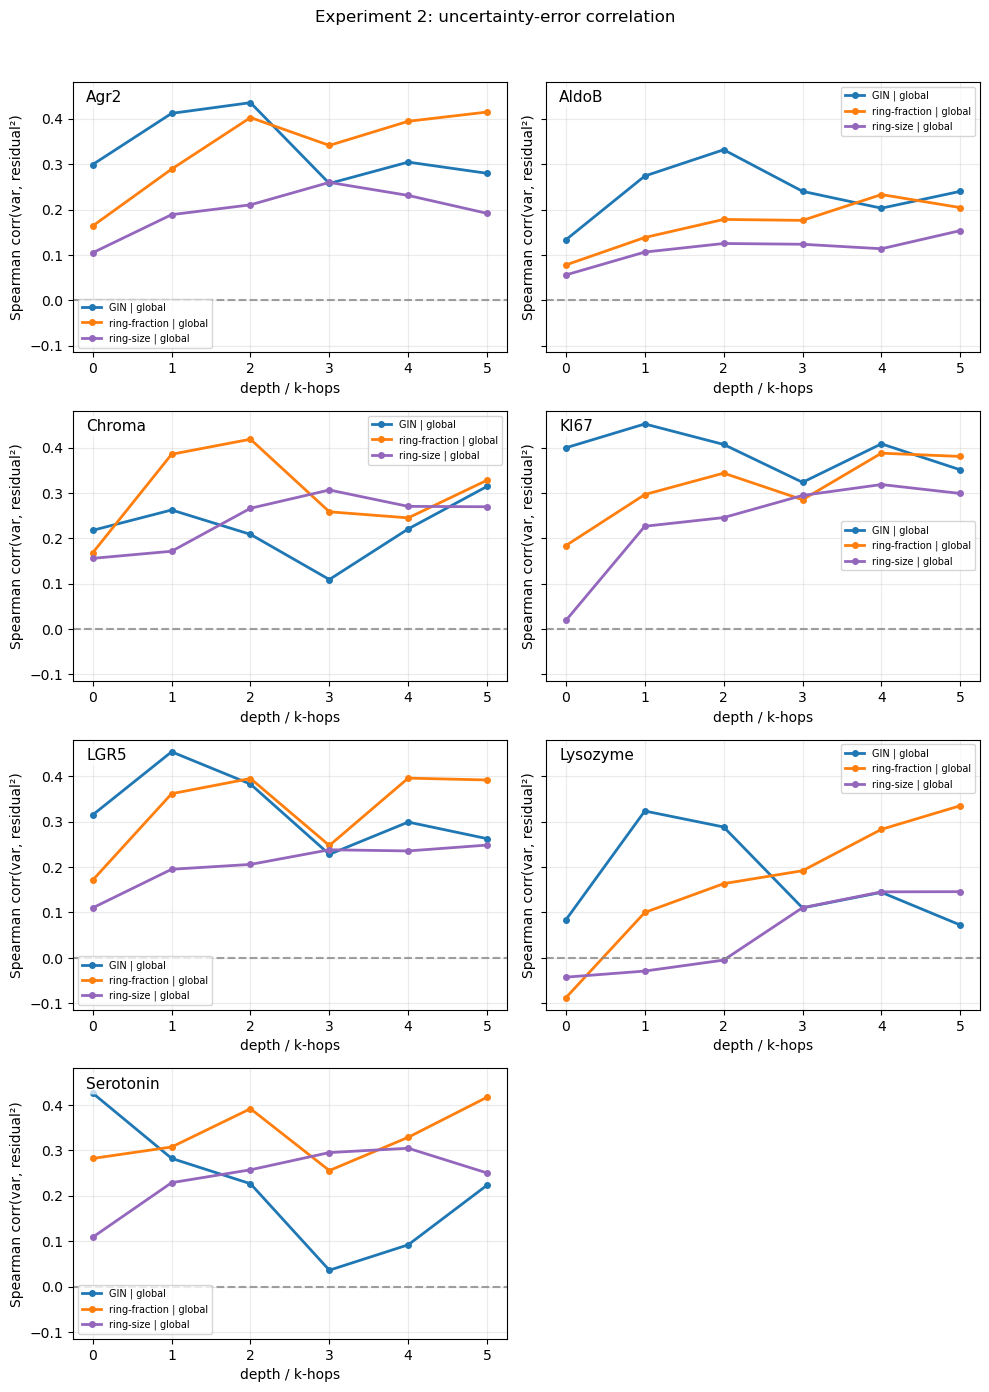

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/run_20260506_115803/figures/exp2_uncertainty_error_correlation_all_nodes_vs_depth.pdf


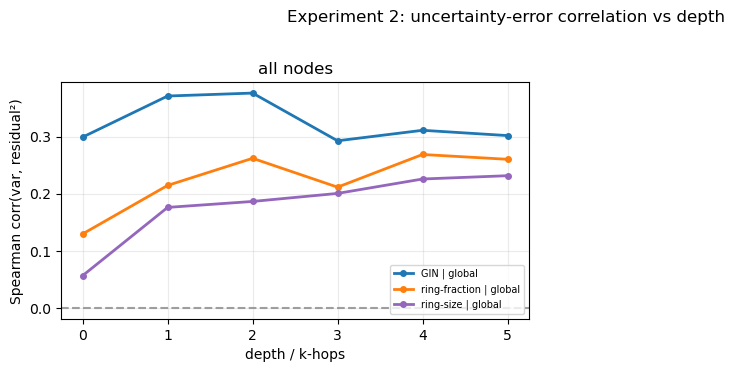

In [19]:
fig, axes = plot_markerwise_metric_vs_depth(
    all_results=all_results_exp2,
    depths=DEPTHS,
    marker_names=marker_names,
    metric_key="rho_marker",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Experiment 2: uncertainty-error correlation",
    family_order=family_order,
    family_colors=family_colors,
    sharey=True,
)
save_mpl_figure(fig, "exp2_uncertainty_error_correlation_markerwise_vs_depth")
plt.show()

fig, axes = plot_all_aggregates_metric_vs_depth(
    all_results_exp2,
    DEPTHS,
    aggregate_keys=("all_nodes",),
    metric_key="rho",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Experiment 2: uncertainty-error correlation vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp2_uncertainty_error_correlation_all_nodes_vs_depth")
plt.show()


## Experiment 3: Ring-preserving permutation

Here we evaluate all trained model families on validation subgraphs where marker features are permuted only within each k-hop ring around the center.


In [20]:
# ============================================================
# Experiment 3: ring-permuted validation subgraphs
# Evaluate ONLY GIN models, separately for each variant
# ============================================================

from src.data.permutation import permute_ego_neighborhood_within_rings

ring_permuted_val_subgraphs_by_variant = {}
all_results_exp3_by_variant = {}

for variant_name, pack in variant_data.items():
    ring_permuted_val_subgraphs = permute_ego_neighborhood_within_rings(
        sampled_val_subgraphs_by_variant[variant_name],
        k_hops=K_MAX,
    )
    ring_permuted_val_subgraphs_by_variant[variant_name] = ring_permuted_val_subgraphs

    gin_only_models = {
        family_name: model_family
        for family_name, model_family in trained_models_by_variant[variant_name].items()
        if "GIN" in family_name
    }

    if len(gin_only_models) == 0:
        raise ValueError(
            f"No GIN models found for variant {variant_name!r}. "
            f"Available families: {list(trained_models_by_variant[variant_name].keys())}"
        )

    all_results_exp3_by_variant[variant_name] = evaluate_family_models(
        trained_models=gin_only_models,
        eval_subgraphs=ring_permuted_val_subgraphs,
        device=device,
        target_transform=pack["target_transform"],
        center_only=True,
    )

all_results_exp3 = flatten_variant_results(all_results_exp3_by_variant)
print("Experiment 3 families:", list(all_results_exp3.keys()))

Experiment 3 families: ['GIN | global']


In [21]:
import math

def plot_two_result_sets_one_family(
    results_a,
    results_b,
    family,
    metric_key,
    sem_key=None,
    baseline_key=None,
    baseline_sem_key=None,
    ylabel="",
    title="",
    label_a="original",
    label_b="ring-permuted",
    color_a="#1f77b4",
    color_b="#d62728",
):
    n_markers = len(marker_names)
    n_cols = 2
    n_rows = math.ceil(n_markers / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3.2 * n_rows), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, mi, mname in zip(axes, range(n_markers), marker_names):
        y_a = results_a[family][metric_key][:, mi]
        y_b = results_b[family][metric_key][:, mi]

        ax.plot(DEPTHS, y_a, "-o", color=color_a, linewidth=2, markersize=4, label=label_a)
        ax.plot(DEPTHS, y_b, "-o", color=color_b, linewidth=2, markersize=4, label=label_b)

        if sem_key is not None:
            s_a = results_a[family][sem_key][:, mi]
            s_b = results_b[family][sem_key][:, mi]
            ax.fill_between(DEPTHS, y_a - s_a, y_a + s_a, color=color_a, alpha=0.15)
            ax.fill_between(DEPTHS, y_b - s_b, y_b + s_b, color=color_b, alpha=0.15)

        if baseline_key is not None:
            y0 = results_a[family][baseline_key][mi]
            ax.axhline(y0, linestyle="--", color="#888888", alpha=0.8, label="baseline")

            if baseline_sem_key is not None:
                s0 = results_a[family][baseline_sem_key][mi]
                ax.fill_between(DEPTHS, y0 - s0, y0 + s0, color="#888888", alpha=0.12)

        ax.set_title(mname)
        ax.set_xlabel("depth / k-hops")
        ax.set_ylabel(ylabel)
        ax.set_xticks(DEPTHS)
        ax.legend(fontsize=7)

    for ax in axes[n_markers:]:
        ax.set_visible(False)

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    return fig


def plot_two_result_sets_one_family_aggregate(
    results_a,
    results_b,
    family,
    depths,
    *,
    aggregate_key="all_nodes",
    metric_key,
    sem_key=None,
    baseline_key=None,
    baseline_sem_key=None,
    ylabel="",
    title="",
    label_a="original",
    label_b="ring-permuted",
    color_a="#1f77b4",
    color_b="#d62728",
    baseline_color="#888888",
    legend_fontsize=8,
    fill_alpha=0.15,
    baseline_fill_alpha=0.12,
    figsize=(7, 4),
):
    if family not in results_a:
        raise KeyError(f"{family!r} not found in results_a")
    if family not in results_b:
        raise KeyError(f"{family!r} not found in results_b")

    x = np.asarray(depths)

    fig, ax = plt.subplots(figsize=figsize)

    y_a = np.asarray(results_a[family]["aggregate"][aggregate_key][metric_key], dtype=float)
    y_b = np.asarray(results_b[family]["aggregate"][aggregate_key][metric_key], dtype=float)

    ax.plot(x, y_a, "-o", color=color_a, linewidth=2, markersize=4, label=label_a)
    ax.plot(x, y_b, "-o", color=color_b, linewidth=2, markersize=4, label=label_b)

    if sem_key is not None:
        s_a = np.asarray(results_a[family]["aggregate"][aggregate_key][sem_key], dtype=float)
        s_b = np.asarray(results_b[family]["aggregate"][aggregate_key][sem_key], dtype=float)

        ax.fill_between(x, y_a - s_a, y_a + s_a, color=color_a, alpha=fill_alpha)
        ax.fill_between(x, y_b - s_b, y_b + s_b, color=color_b, alpha=fill_alpha)

    if baseline_key is not None:
        y0 = results_a[family]["aggregate"][aggregate_key][baseline_key]
        y0 = float(y0[0]) if np.ndim(y0) > 0 else float(y0)

        ax.axhline(y0, linestyle="--", color=baseline_color, alpha=0.8, label="baseline")

        if baseline_sem_key is not None:
            s0 = results_a[family]["aggregate"][aggregate_key][baseline_sem_key]
            s0 = float(s0[0]) if np.ndim(s0) > 0 else float(s0)

            ax.fill_between(x, y0 - s0, y0 + s0, color=baseline_color, alpha=baseline_fill_alpha)

    pretty_names = {
        "all_nodes": "all nodes",
        "any_marker": "marker-positive nodes",
        "no_marker": "marker-negative nodes",
    }

    ax.set_title(pretty_names.get(aggregate_key, aggregate_key))
    ax.set_xlabel("depth / k-hops")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.legend(fontsize=legend_fontsize)

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    return fig, ax

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/run_20260506_115803/figures/exp3_GIN_global_original_vs_ring_permuted_markerwise_mse.pdf


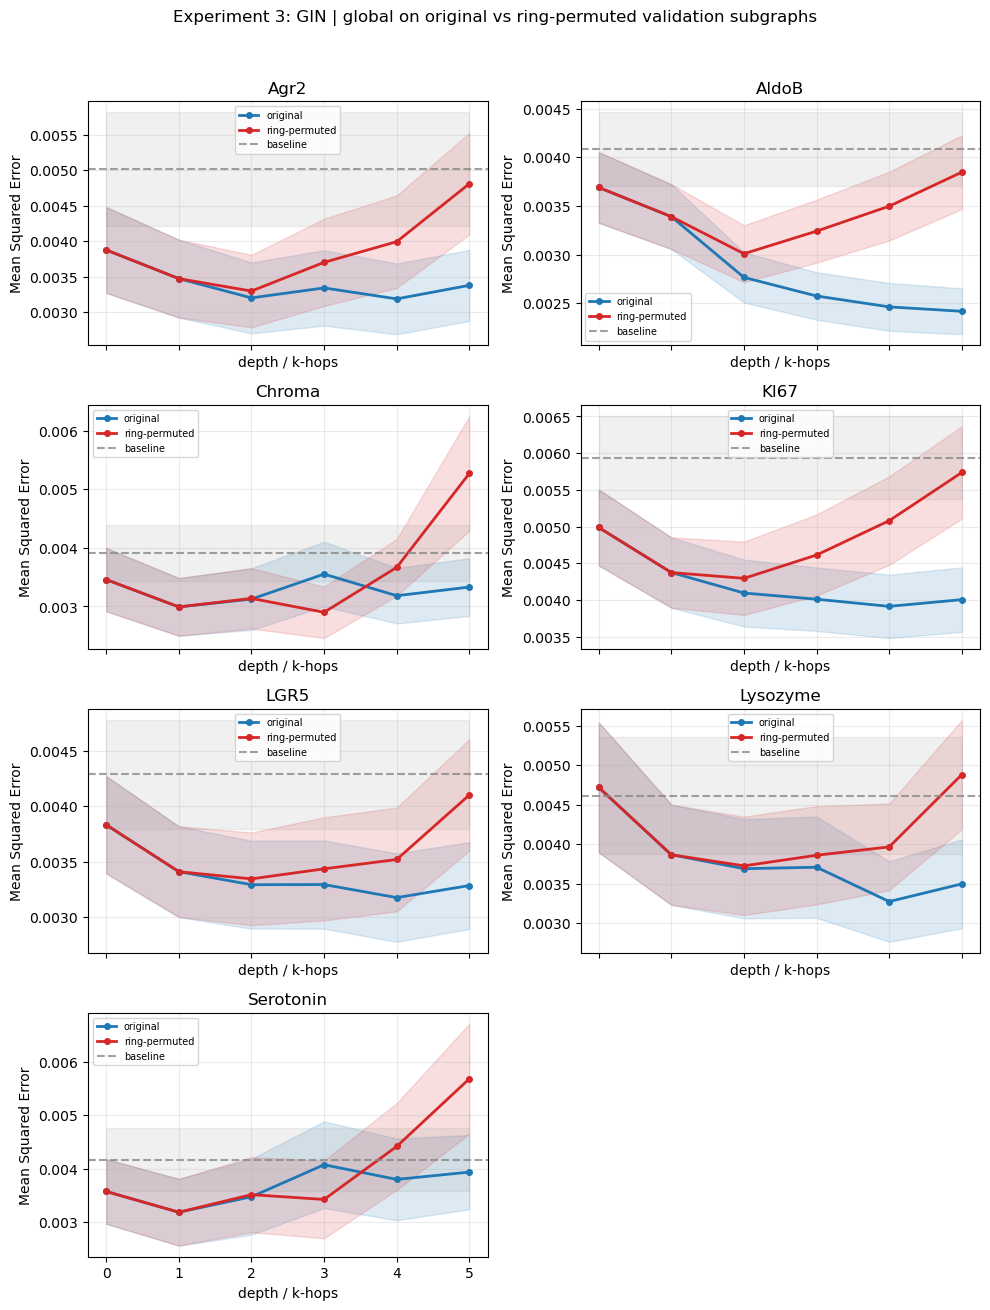

In [22]:
gin_families_exp3 = [family for family in all_results_exp3.keys() if "GIN" in family]

for family in gin_families_exp3:
    fig = plot_two_result_sets_one_family(
        all_results_exp1,
        all_results_exp3,
        family=family,
        metric_key="mse_model",
        sem_key="sem_mse_model",
        baseline_key="mse_base",
        baseline_sem_key="sem_mse_base",
        ylabel="Mean Squared Error",
        title=f"Experiment 3: {family} on original vs ring-permuted validation subgraphs",
        label_a="original",
        label_b="ring-permuted",
    )
    save_mpl_figure(fig, f"exp3_{family}_original_vs_ring_permuted_markerwise_mse")
    plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/run_20260506_115803/figures/exp3_GIN_global_original_vs_ring_permuted_all_nodes_mse.pdf


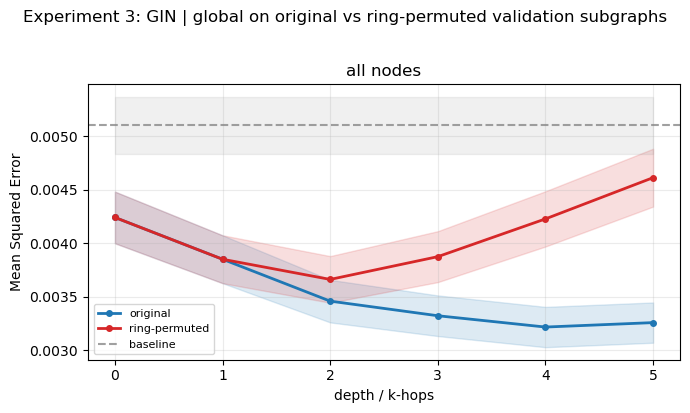

In [23]:
gin_families_exp3 = [family for family in all_results_exp3.keys() if "GIN" in family]

for family in gin_families_exp3:
    for aggregate_key in ["all_nodes"]:
        fig, ax = plot_two_result_sets_one_family_aggregate(
            all_results_exp1,
            all_results_exp3,
            family=family,
            depths=DEPTHS,
            aggregate_key=aggregate_key,
            metric_key="mse_model",
            sem_key="sem_mse_model",
            baseline_key="mse_base",
            baseline_sem_key="sem_mse_base",
            ylabel="Mean Squared Error",
            title=f"Experiment 3: {family} on original vs ring-permuted validation subgraphs",
            label_a="original",
            label_b="ring-permuted",
        )
        save_mpl_figure(fig, f"exp3_{family}_original_vs_ring_permuted_{aggregate_key}_mse")
        plt.show()


## Summarize results

In [24]:

def summarize_results(flat_results, *, experiment_name, depths):
    rows = []
    for family_label, res in flat_results.items():
        for depth_idx, depth in enumerate(depths):
            row = {
                "experiment": experiment_name,
                "family": family_label,
                "depth": int(depth),
                "mse_all_nodes": float(res["aggregate"]["all_nodes"]["mse_model"][depth_idx]),
                "nll_all_nodes": float(res["aggregate"]["all_nodes"]["nll_model"][depth_idx]),
                "rho_all_nodes": float(res["aggregate"]["all_nodes"]["rho"][depth_idx]),
            }
            rows.append(row)
    return pd.DataFrame(rows)

summary_df = pd.concat(
    [
        summarize_results(all_results_exp1, experiment_name="exp1_original", depths=DEPTHS),
        summarize_results(all_results_exp2, experiment_name="exp2_center_preserving_permuted", depths=DEPTHS),
        summarize_results(all_results_exp3, experiment_name="exp3_ring_preserving_permuted", depths=DEPTHS),
    ],
    ignore_index=True,
)

summary_df.sort_values(["experiment", "family", "depth"]).head(20)


,experiment,family,depth,mse_all_nodes,nll_all_nodes,rho_all_nodes
0,exp1_original,GIN | global,0,0.004240,-1.179237,0.299127
1,exp1_original,GIN | global,1,0.003850,-1.252097,0.284579
2,exp1_original,GIN | global,2,0.003458,-1.365476,0.320845
3,exp1_original,GIN | global,3,0.003321,-1.411439,0.332041
4,exp1_original,GIN | global,4,0.003216,-1.470784,0.326527
5,exp1_original,GIN | global,5,0.003257,-1.420161,0.304277
6,exp1_original,ring-fraction | global,0,0.004430,-1.026809,0.129643
7,exp1_original,ring-fraction | global,1,0.004170,-1.093880,0.200256
8,exp1_original,ring-fraction | global,2,0.003969,-1.263137,0.284346
9,exp1_original,ring-fraction | global,3,0.003822,-1.280299,0.298050


## Save the results

In [25]:

def _jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_jsonable(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, torch.dtype):
        return str(obj)
    if isinstance(obj, np.dtype):
        return str(obj)
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

def save_joint_experiment(save_dir, config, results_by_experiment, notes=None):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    with open(save_dir / "config.json", "w") as f:
        json.dump(_jsonable(config), f, indent=2)

    with open(save_dir / "results.pkl", "wb") as f:
        pickle.dump(results_by_experiment, f)

    meta = {
        "timestamp": datetime.now().isoformat(),
        "notes": notes,
        "experiments": list(results_by_experiment.keys()),
    }
    with open(save_dir / "meta.json", "w") as f:
        json.dump(_jsonable(meta), f, indent=2)

    print(f"Saved joint experiment -> {save_dir}")


In [26]:

save_dir = SAVE_DIR

joint_config = {
    "experiment_group": EXPERIMENT_GROUP,
    "data_subdir": DATA_SUBDIR,
    "model_families": MODEL_FAMILIES,
    "use_global_features": USE_GLOBAL_FEATURES,
    "feature_variants": FEATURE_VARIANTS,
    "depths": DEPTHS.tolist(),
    "hidden_dim": BASE_HIDDEN_DIM,
    "dropout": BASE_DROPOUT,
    "norm": BASE_NORM,
    "K_MAX": K_MAX,
    "val_frac": VAL_FRAC,
    "split_seed": SPLIT_SEED,
    "sphericity_max": SPHERICITY_MAX,
    "spherical_marker_diversity_min": SPHERICAL_MARKER_DIVERSITY_MIN,
    "complexity_min": COMPLEXITY_MIN,
    "outlier_clip_quantiles": OUTLIER_CLIP_QUANTILES,
    "target_indices": TARGET_INDICES,
    "target_labels": TARGET_LABELS,
    "field_specs": field_specs,
    "train_config": {
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "num_workers": NUM_WORKERS,
        "edge_loss_params": {
            "weight": EDGE_LOSS_WEIGHT,
            "weighted": False,
            "alpha": 2.0,
            "normalize_by": "graph_std",
            "clip_weight": 4.0,
        },
    },
    "n_train_graphs": len(base_train),
    "n_val_graphs": len(base_val),
    "n_sampled_subgraphs_by_variant": {
        k: len(v) for k, v in sampled_val_subgraphs_by_variant.items()
    },
    "marker_names": list(marker_names),
    "figures_dir": str(FIGURES_DIR),
}

results_by_experiment = {
    "exp1_original": all_results_exp1_by_variant,
    "exp2_center_preserving_permuted": all_results_exp2_by_variant,
    "exp3_ring_preserving_permuted": all_results_exp3_by_variant,
    "training_logs": training_logs,
    "summary_table": summary_df.to_dict(orient="records"),
}

save_joint_experiment(
    save_dir=save_dir,
    config=joint_config,
    results_by_experiment=results_by_experiment,
    notes=("Redone experiment after refactor"),
)


Saved joint experiment -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/run_20260506_115803
